In [2]:
import numpy as np
import matplotlib.pyplot as plt
import os

In [3]:
# Step 2: Load ONE image and inspect it
sample_path = "dataset/train/no/2.npy"  # one .npy file

image = np.load(sample_path)

print("Shape:", image.shape)   # e.g. (150, 150) or (150, 150, 1)
print("Min value:", image.min())
print("Max value:", image.max())
print("Data type:", image.dtype)

Shape: (1, 150, 150)
Min value: 0.0
Max value: 1.0
Data type: float64


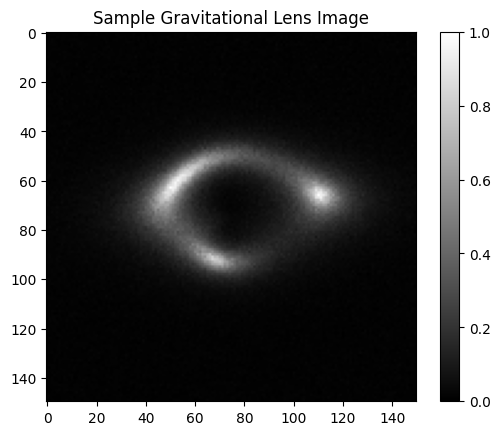

In [4]:
# Step 3: See what the image actually looks like
plt.imshow(image.squeeze(), cmap='gray')  
# .squeeze() removes dimensions of size 1, e.g. (150,150,1) → (150,150)
plt.title("Sample Gravitational Lens Image")
plt.colorbar()
plt.show()

In [6]:
import os

data_dir = "dataset/train"  # change this

all_paths = []
all_labels = []

# os.listdir gives you the folder names — which are your class names
classes = sorted([
    cls for cls in os.listdir(data_dir)
    if os.path.isdir(os.path.join(data_dir, cls))
])
# sorted() so order is consistent every run

# Build a dictionary: class name → number
class_to_idx = {cls: idx for idx, cls in enumerate(classes)}

print("Classes found:", classes)
print("Class to index:", class_to_idx)

# Now walk through each class folder
for cls in classes:
    cls_folder = os.path.join(data_dir, cls)
    for filename in os.listdir(cls_folder):
        filepath = os.path.join(cls_folder, filename)
        all_paths.append(filepath)
        all_labels.append(class_to_idx[cls])

print(f"\nTotal images found: {len(all_paths)}")
print("First 3 paths:", all_paths[:3])
print("First 3 labels:", all_labels[:3])

Classes found: ['no', 'sphere', 'vort']
Class to index: {'no': 0, 'sphere': 1, 'vort': 2}

Total images found: 30000
First 3 paths: ['dataset/train/no/4526.npy', 'dataset/train/no/4566.npy', 'dataset/train/no/5950.npy']
First 3 labels: [0, 0, 0]


In [7]:
val_dir = "dataset/val"

val_paths = []
val_labels = []

for cls in classes:
    cls_folder = os.path.join(val_dir, cls)
    for filename in os.listdir(cls_folder):
        filepath = os.path.join(cls_folder, filename)
        val_paths.append(filepath)
        val_labels.append(class_to_idx[cls])

print(f"Total val images: {len(val_paths)}")

# Check class balance
from collections import Counter
print("Val class distribution:", Counter(val_labels))

Total val images: 7500
Val class distribution: Counter({0: 2500, 1: 2500, 2: 2500})


In [8]:
from sklearn.model_selection import train_test_split


val_paths, test_paths, val_labels, test_labels = train_test_split(
    val_paths,
    val_labels,
    test_size=0.5,        # 50% goes to test
    random_state=42,      # fixed seed so split is same every run
    stratify=val_labels   # keep class balance in both halves
)

print(f"Val size: {len(val_paths)}")
print(f"Test size: {len(test_paths)}")
print("Val distribution:", Counter(val_labels))
print("Test distribution:", Counter(test_labels))

Val size: 3750
Test size: 3750
Val distribution: Counter({1: 1250, 0: 1250, 2: 1250})
Test distribution: Counter({2: 1250, 1: 1250, 0: 1250})
